In [1]:
SEED = 24520789


In [2]:
# Reproducibility enforcement and quick seed check
import os, random, numpy as np, torch

# Ensure PYTHON hash seed is stable
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Prefer deterministic algorithms when available, but do not fail on ops that lack
# deterministic CUDA implementations. The smoke-test cell below only needs to verify
# that the RNG stream is repeatable.
try:
    torch.use_deterministic_algorithms(False, warn_only=True)
    print('torch.use_deterministic_algorithms(False, warn_only=True) enabled')
except TypeError:
    try:
        torch.use_deterministic_algorithms(False)
        print('torch.use_deterministic_algorithms(False) enabled')
    except Exception as e:
        print('Could not enable torch.use_deterministic_algorithms:', e)
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True
        print('Falling back to cudnn deterministic mode')

# Quick seed check: sample twice after reseeding
def _sample_once():
    return {
        'py_random': [random.random() for _ in range(3)],
        'np_rand': np.random.rand(3).tolist(),
        'torch_cpu': torch.rand(3).tolist(),
    }

a = _sample_once()
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
b = _sample_once()
print('Seed check match:', a == b)
print('Sample (1):', a)
print('Sample (2):', b)


torch.use_deterministic_algorithms(False, warn_only=True) enabled
Seed check match: True
Sample (1): {'py_random': [0.9459758336886895, 0.22906676069050858, 0.027838354396150677], 'np_rand': [0.9834658404741958, 0.8101150811275819, 0.7300948332552615], 'torch_cpu': [0.7672545909881592, 0.558594822883606, 0.38946056365966797]}
Sample (2): {'py_random': [0.9459758336886895, 0.22906676069050858, 0.027838354396150677], 'np_rand': [0.9834658404741958, 0.8101150811275819, 0.7300948332552615], 'torch_cpu': [0.7672545909881592, 0.558594822883606, 0.38946056365966797]}


# HaGRID 5-Class Object Detection (PyTorch From Scratch)

This notebook does the following:
1. Downloads HaGRID from Kaggle.
2. Builds and trains custom object detection models from scratch in PyTorch.
3. Compares model quality and speed (accuracy, precision, recall, IoU, and latency in ms).

Target classes in this notebook:
- `one` (gesture 1)
- `peace` (gesture 2)
- `three` (gesture 3)
- `four` (gesture 4)
- `fist`


In [3]:
from pathlib import Path
import os
import sys

# Essential imports needed before validation checks
import torch

def get_environment() -> str:
    """
    Detect the current execution environment: 'kaggle', 'colab', or 'local'.
    Returns a string representing the environment.
    """
    # Kaggle environment check
    if os.getenv("KAGGLE_DATA_FOLDER") or os.path.exists("/kaggle/input"):
        return "kaggle"
    
    # Colab environment check
    try:
        import google.colab  # type: ignore
        return "colab"
    except ImportError:
        pass
    
    if os.getenv("COLAB_GPU") or os.getenv("COLAB_TPU_ADDR"):
        return "colab"
    
    if os.path.exists("/content") and os.getcwd().startswith("/content"):
        return "colab"
    
    # Default to local
    return "local"

ENVIRONMENT = get_environment()
print(f"Detected environment: {ENVIRONMENT}")

# Set up paths based on environment
if ENVIRONMENT == "kaggle":
    # Kaggle environment
    DATASET_ROOT = Path("/kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p")
    MODEL_DIR = Path("/kaggle/working/models")
    OUTPUT_DIR = Path("/kaggle/working")
    
elif ENVIRONMENT == "colab":
    # Colab environment
    DATASET_ROOT = Path("/content/hagrid_dataset/hagrid-sample-30k-384p")
    MODEL_DIR = Path("/content/models")
    OUTPUT_DIR = Path("/content")
    
else:
    # Local environment
    REPO_ROOT = Path(".").resolve()
    DATASET_ROOT = REPO_ROOT / "data" / "hagrid-sample-30k-384p-5class"
    MODEL_DIR = REPO_ROOT / "models"
    OUTPUT_DIR = REPO_ROOT

# Create necessary directories (safe for all environments)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Set up device for GPU/CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Dataset root: {DATASET_ROOT}")
print(f"Model directory: {MODEL_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Device: {device}")


Detected environment: kaggle
Dataset root: /kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p
Model directory: /kaggle/working/models
Output directory: /kaggle/working
Device: cuda


In [4]:
# Environment validation and diagnostic checks
print("\n" + "="*70)
print("ENVIRONMENT VALIDATION & DIAGNOSTIC CHECKS")
print("="*70)

# Check 1: Environment detection
print(f"\n1. Environment: {ENVIRONMENT}")
if ENVIRONMENT == "kaggle":
    print("   ✓ Running on Kaggle")
elif ENVIRONMENT == "colab":
    print("   ✓ Running on Google Colab")
else:
    print("   ✓ Running locally")

# Check 2: Path validation
print(f"\n2. Path Configuration:")
print(f"   Dataset root: {DATASET_ROOT}")
print(f"   Dataset exists: {DATASET_ROOT.exists()}")
print(f"   Model directory: {MODEL_DIR}")
print(f"   Model dir exists: {MODEL_DIR.exists()}")
print(f"   Output directory: {OUTPUT_DIR}")
print(f"   Output dir exists: {OUTPUT_DIR.exists()}")

# Check 3: GPU/Device availability
print(f"\n3. Hardware Status:")
print(f"   Device: {device}")
print(f"   CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"   GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("   NOTE: Running on CPU (slower, but code will work)")

# Check 4: Dataset structure
print(f"\n4. Dataset Structure Validation:")
if DATASET_ROOT.exists():
    ann_dir = DATASET_ROOT / "ann_train_val"
    img_root = DATASET_ROOT / "hagrid_30k"
    print(f"   Annotations dir: {ann_dir.exists()}")
    print(f"   Images root: {img_root.exists()}")
    
    if ann_dir.exists():
        json_count = len(list(ann_dir.glob("*.json")))
        print(f"   JSON annotation files: {json_count}")
    
    if img_root.exists():
        subdirs = [d.name for d in img_root.iterdir() if d.is_dir()]
        print(f"   Image subdirectories: {subdirs}")
else:
    print("   ⚠ Dataset root does not exist yet (will be needed for training)")

# Check 5: Package availability
print(f"\n5. Required Packages:")
packages_ok = True
try:
    import torch as _
    print("   ✓ PyTorch")
except:
    print("   ✗ PyTorch MISSING")
    packages_ok = False

try:
    import torchvision as _
    print("   ✓ torchvision")
except:
    print("   ✗ torchvision MISSING")
    packages_ok = False

try:
    from PIL import Image as _
    print("   ✓ PIL")
except:
    print("   ✗ PIL MISSING")
    packages_ok = False

try:
    import pandas as _
    print("   ✓ pandas")
except:
    print("   ✗ pandas MISSING")
    packages_ok = False

try:
    import cv2 as _
    print("   ✓ opencv-python")
except:
    print("   ✗ opencv-python MISSING")
    packages_ok = False

print("\n" + "="*70)
if packages_ok:
    print("✓ ALL CHECKS PASSED - Ready for training!")
else:
    print("⚠ Some packages are missing - see above")
print("="*70 + "\n")



ENVIRONMENT VALIDATION & DIAGNOSTIC CHECKS

1. Environment: kaggle
   ✓ Running on Kaggle

2. Path Configuration:
   Dataset root: /kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p
   Dataset exists: True
   Model directory: /kaggle/working/models
   Model dir exists: True
   Output directory: /kaggle/working
   Output dir exists: True

3. Hardware Status:
   Device: cuda
   CUDA available: True
   GPU Name: Tesla T4
   GPU Memory: 15.64 GB

4. Dataset Structure Validation:
   Annotations dir: True
   Images root: True
   JSON annotation files: 18
   Image subdirectories: ['train_val_call', 'train_val_three', 'train_val_two_up_inverted', 'train_val_four', 'train_val_two_up', 'train_val_peace', 'train_val_three2', 'train_val_like', 'train_val_rock', 'train_val_stop', 'train_val_ok', 'train_val_fist', 'train_val_dislike', 'train_val_mute', 'train_val_one', 'train_val_peace_inverted', 'train_val_palm', 'train_val_stop_inverted']

5. Required Packages:
   

In [5]:
import os
import json
import time
import random
import shutil
import subprocess
import hashlib
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

try:
    import torchmetrics
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchmetrics"])
    import torchmetrics
from torchmetrics.detection.mean_ap import MeanAveragePrecision
from sklearn.metrics import classification_report, confusion_matrix

# SEED is defined in cell 1; set random seeds for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Also set CUDA seeds for reproducibility on GPU
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# device is already defined in cell 2 (environment setup)
# Verify device is available
print("Imports complete:")
print(f"  Device: {device}")
print(f"  CUDA available: {torch.cuda.is_available()}")

# Note: REPO_ROOT and DATA_ROOT are now set in cell 2 via ENVIRONMENT detection
# This avoids conflicts with the environment-aware paths defined there.
# REGISTRY_PATH is used only for logging/diagnostics, not critical for core functionality.

REGISTRY_PATH = Path(".").resolve() / "dataset_registry.json"

def load_registry(path: Path):
    if path.exists():
        try:
            return json.loads(path.read_text(encoding="utf-8"))
        except Exception:
            pass
    return {"datasets": {}}

def save_registry(path: Path, registry: dict):
    path.write_text(json.dumps(registry, indent=2), encoding="utf-8")

def sha1_of_file(path: Path):
    if not path.exists():
        return None
    h = hashlib.sha1()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

def ensure_kaggle_installed():
    try:
        import kaggle  # noqa: F401
        print("kaggle package already available in notebook kernel")
    except Exception:
        print("Installing kaggle package in notebook kernel...")
        subprocess.check_call(["python", "-m", "pip", "install", "-q", "kaggle"])
        import kaggle  # noqa: F401
        print("kaggle package installed")


Imports complete:
  Device: cuda
  CUDA available: True


## 1) One-Time Kaggle Setup + Filtered 5-Class Dataset

This section does all of this:
- Uses the Kaggle token file from `C:/Users/<you>/.kaggle/access_token.txt`.
- Detects if the filtered HaGRID Sample 30k 384p 5-class dataset is already present in this repo.
- Builds a repo-local filtered copy that keeps only the five train classes: `one`, `peace`, `three`, `four`, `fist`.
- Stores dataset metadata in `dataset_registry.json` at repo root.
- Verifies the reduced dataset afterward by counting only the kept image folders and annotation JSONs.

Dataset reference: `innominate817/hagrid-sample-30k-384p`.

Important:
- The notebook now uses the filtered 5-class copy stored at `data/hagrid-sample-30k-384p-5class`.
- The later parsing/training cells work with that filtered dataset root.


In [6]:
# Verify dataset root and prepare dataset loading
print(f"Environment: {ENVIRONMENT}")
print(f"Using dataset root: {DATASET_ROOT}")
print(f"Dataset exists: {DATASET_ROOT.exists()}")

if DATASET_ROOT.exists():
    json_files = list(DATASET_ROOT.rglob("*.json"))
    jpg_files = list(DATASET_ROOT.rglob("*.jpg"))
    print(f"JSON files: {len(json_files)}")
    print(f"JPG files: {len(jpg_files)}")
    
    # For Kaggle, list directory structure to understand format
    if ENVIRONMENT == "kaggle" and DATASET_ROOT.exists():
        print("\nDataset structure (Kaggle HaGrid):")
        for item in list(DATASET_ROOT.iterdir())[:10]:
            print(f"  {item.name}")


Environment: kaggle
Using dataset root: /kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p
Dataset exists: True
JSON files: 18
JPG files: 31833

Dataset structure (Kaggle HaGrid):
  ann_train_val
  hagrid_30k


In [7]:
KEEP_CLASSES = ["one", "peace", "three", "four", "fist"]
TARGET_CLASSES = KEEP_CLASSES
CLASS_TO_ID = {c: i for i, c in enumerate(TARGET_CLASSES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

print(f"Target classes: {TARGET_CLASSES}")
print(f"Class to ID mapping: {CLASS_TO_ID}")

def find_json_files(root: Path):
    return [p for p in root.rglob("*.json") if p.is_file()]

def build_filename_index(root: Path):
    """Scan the repo dataset once and index image stems to absolute paths."""
    filename_index = {}
    for img_path in root.rglob("*"):
        if img_path.is_file() and img_path.suffix.lower() in IMG_EXTS:
            filename_index.setdefault(img_path.name, img_path)
            filename_index.setdefault(img_path.stem, img_path)
    return filename_index

def resolve_image_path(filename_index: dict, image_key: str):
    key = Path(image_key).stem
    return filename_index.get(key) or filename_index.get(Path(image_key).name)

def xywh_to_xyxy(box, w, h, normalized=True):
    x, y, bw, bh = box
    if normalized:
        x *= w
        y *= h
        bw *= w
        bh *= h
    x1 = max(0.0, x)
    y1 = max(0.0, y)
    x2 = min(float(w - 1), x + bw)
    y2 = min(float(h - 1), y + bh)
    return [x1, y1, x2, y2]

def parse_hagrid_annotations(dataset_root: Path, target_classes, environment: str):
    """
    Parse HaGRID annotations based on environment.
    
    Local format:
    - ann_train_val/{class}.json
    - hagrid_30k/train_val_{class}/<image_id>.jpg
    
    Kaggle format (full dataset):
    - ann_train_val/{class}.json  (same structure as local)
    - hagrid_30k/train_val_{class}/<image_id>.jpg (same structure as local)
    
    Returns list of records with fields: image_path, bbox_xyxy, class_id
    """
    ann_dir = dataset_root / "ann_train_val"
    img_root = dataset_root / "hagrid_30k"
    
    print(f"Looking for annotations in: {ann_dir}")
    print(f"Looking for images in: {img_root}")
    
    # Find JSON files for target classes
    json_files = []
    for class_name in target_classes:
        json_path = ann_dir / f"{class_name}.json"
        if json_path.exists():
            json_files.append(json_path)
        else:
            print(f"Warning: {json_path} not found")
    
    print(f"Found {len(json_files)} annotation files for target classes")
    
    if not json_files:
        print("ERROR: No annotation files found! Check dataset structure.")
        return []
    
    print("Building filename index once (this may take a minute for Kaggle)...")
    filename_index = build_filename_index(img_root)
    print(f"Indexed {len(filename_index)} image-name entries")

    records = []
    skipped_missing_image = 0
    skipped_bad_json = 0
    skipped_non_target_class = 0

    for jf in tqdm(json_files, desc="Parsing annotations"):
        if not jf.exists():
            continue
        try:
            data = json.loads(jf.read_text(encoding="utf-8"))
        except Exception as e:
            print(f"Error reading {jf}: {e}")
            skipped_bad_json += 1
            continue

        if not isinstance(data, dict):
            skipped_bad_json += 1
            continue

        for image_key, item in data.items():
            if not isinstance(item, dict):
                continue

            labels = item.get("labels") or []
            bboxes = item.get("bboxes") or []
            if not labels or not bboxes:
                continue

            img_path = resolve_image_path(filename_index, image_key)
            if img_path is None:
                skipped_missing_image += 1
                continue

            try:
                with Image.open(img_path) as img_pil:
                    img_pil = img_pil.convert("RGB")
                    w, h = img_pil.size
            except Exception:
                continue

            for label, box in zip(labels, bboxes):
                if label not in target_classes:
                    skipped_non_target_class += 1
                    continue
                if not isinstance(box, (list, tuple)) or len(box) < 4:
                    continue
                normalized = max(box[:4]) <= 1.5
                x1, y1, x2, y2 = xywh_to_xyxy(box[:4], w, h, normalized=normalized)
                records.append({
                    "image_path": str(img_path),
                    "bbox_xyxy": [x1, y1, x2, y2],
                    "class_id": CLASS_TO_ID[label],
                })

    print(f"Parsing complete:")
    print(f"  Valid records: {len(records)}")
    print(f"  Skipped missing-image: {skipped_missing_image}")
    print(f"  Skipped unreadable JSON: {skipped_bad_json}")
    print(f"  Skipped non-target classes: {skipped_non_target_class}")
    
    return records

# Parse dataset with environment-aware handler
print("\n" + "="*60)
print(f"Parsing HaGRID dataset ({ENVIRONMENT} environment)")
print("="*60)

records = parse_hagrid_annotations(DATASET_ROOT, TARGET_CLASSES, ENVIRONMENT)
print(f"\nParsed records (raw): {len(records)}")

# Filter to single-hand images only (images that appear exactly once)
img_counts = Counter(r['image_path'] for r in records)
single_records = [r for r in records if img_counts[r['image_path']] == 1]
print(f"Records before filter: {len(records)}, after filter (single-hand only): {len(single_records)}")
records = single_records

if len(records) == 0:
    print("ERROR: No samples parsed after single-hand filtering. Check dataset structure and annotation schema.")
else:
    print(f"✓ Successfully parsed {len(records)} single-hand gesture samples")


Target classes: ['one', 'peace', 'three', 'four', 'fist']
Class to ID mapping: {'one': 0, 'peace': 1, 'three': 2, 'four': 3, 'fist': 4}

Parsing HaGRID dataset (kaggle environment)
Looking for annotations in: /kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p/ann_train_val
Looking for images in: /kaggle/input/datasets/innominate817/hagrid-sample-30k-384p/hagrid-sample-30k-384p/hagrid_30k
Found 5 annotation files for target classes
Building filename index once (this may take a minute for Kaggle)...
Indexed 63666 image-name entries


Parsing annotations:   0%|          | 0/5 [00:00<?, ?it/s]

Parsing complete:
  Valid records: 8837
  Skipped missing-image: 132568
  Skipped unreadable JSON: 0
  Skipped non-target classes: 2067

Parsed records (raw): 8837
Records before filter: 8837, after filter (single-hand only): 8837
✓ Successfully parsed 8837 single-hand gesture samples


Train: 6185, Val: 1325, Test: 1327


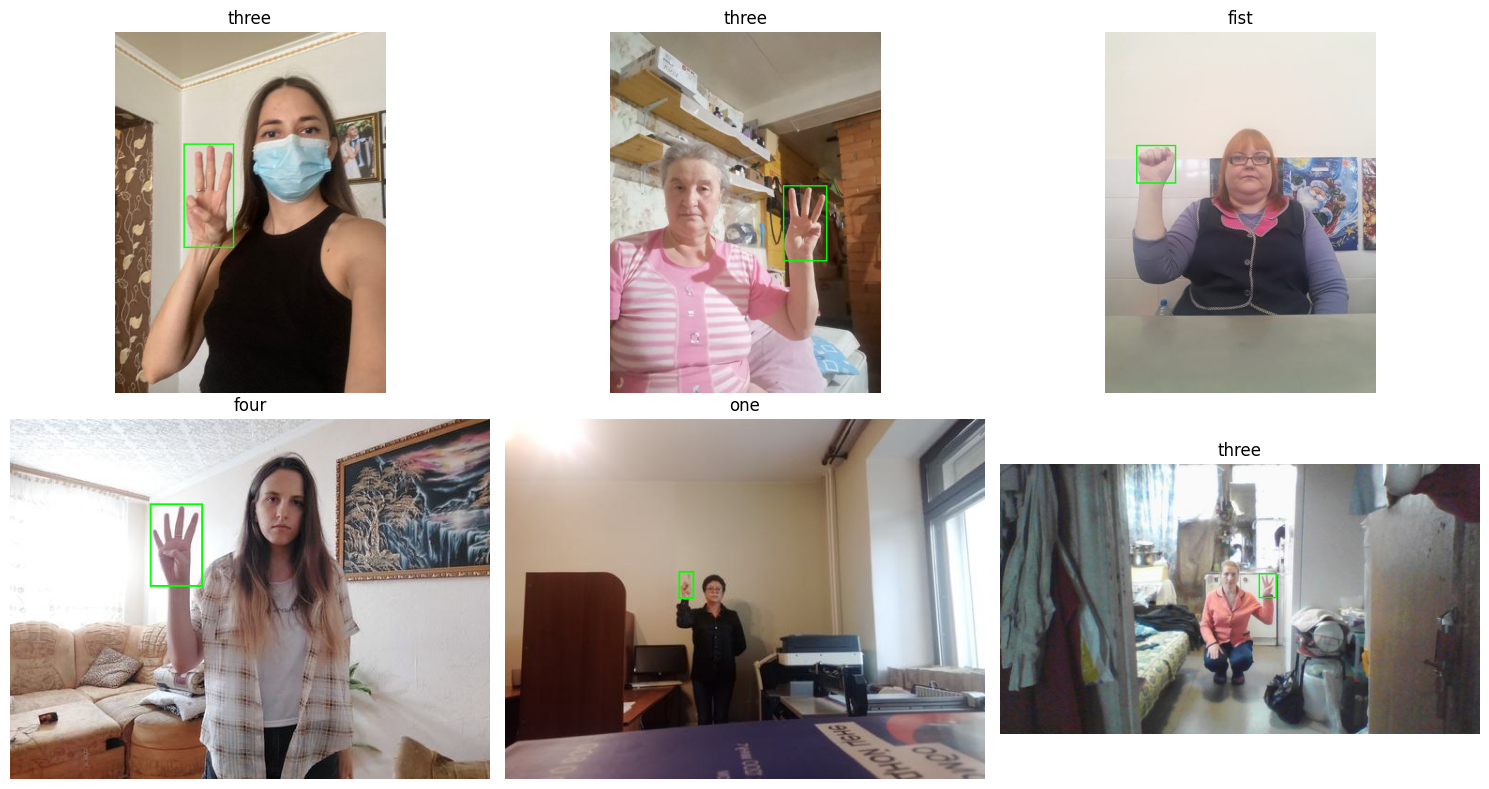

In [8]:
# Use the exact filtered 5-class dataset already prepared in the repo.
random.shuffle(records)

n = len(records)
n_train = int(0.7 * n)
n_val = int(0.15 * n)

train_records = records[:n_train]
val_records = records[n_train:n_train + n_val]
test_records = records[n_train + n_val:]

print(f"Train: {len(train_records)}, Val: {len(val_records)}, Test: {len(test_records)}")


def draw_box(image, box, color, width=2):
    draw = ImageDraw.Draw(image)
    for offset in range(width):
        draw.rectangle(
            [box[0] - offset, box[1] - offset, box[2] + offset, box[3] + offset],
            outline=color,
        )


def show_samples(samples, n_show=6):
    if len(samples) == 0:
        print("No samples to show")
        return
    idxs = np.random.choice(len(samples), size=min(n_show, len(samples)), replace=False)
    plt.figure(figsize=(15, 8))
    for i, idx in enumerate(idxs, 1):
        s = samples[idx]
        with Image.open(s["image_path"]) as img_pil:
            img = img_pil.convert("RGB")
        x1, y1, x2, y2 = map(int, s["bbox_xyxy"])
        draw_box(img, (x1, y1, x2, y2), color=(0, 255, 0), width=2)
        plt.subplot(2, 3, i)
        plt.imshow(img)
        plt.title(ID_TO_CLASS[s["class_id"]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_samples(train_records, n_show=6)


In [9]:
IMG_SIZE = 320
BATCH_SIZE = 32

if ENVIRONMENT in ["kaggle", "colab"]:
    NUM_WORKERS = 2
else:
    import platform
    if platform.system() == "Windows":
        NUM_WORKERS = 0
    else:
        NUM_WORKERS = 2

def normalize_box_xyxy(box, w, h):
    x1, y1, x2, y2 = box
    return [x1 / w, y1 / h, x2 / w, y2 / h]

from torch.utils.data import Dataset, DataLoader
class GestureLocalizationDataset(Dataset):
    def __init__(self, records, img_size=320, augment=False):
        self.records = records
        self.img_size = img_size
        self.augment = augment

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        from PIL import Image
        import numpy as np
        import random
        import torch
        with Image.open(r["image_path"]) as img_pil:
            img = img_pil.convert("RGB")
            w, h = img.size
            x1, y1, x2, y2 = r["bbox_xyxy"]

            if self.augment:
                if random.random() > 0.5:
                    img = img.transpose(Image.FLIP_LEFT_RIGHT)
                    new_x1 = w - x2
                    new_x2 = w - x1
                    x1, x2 = new_x1, new_x2
                if random.random() > 0.5:
                    from PIL import ImageEnhance
                    enhancer = ImageEnhance.Brightness(img)
                    img = enhancer.enhance(random.uniform(0.8, 1.2))

            x1_n, y1_n, x2_n, y2_n = normalize_box_xyxy([x1, y1, x2, y2], w, h)
            img = img.resize((self.img_size, self.img_size), Image.Resampling.BILINEAR)
            img = np.asarray(img, dtype=np.float32) / 255.0
            img = np.transpose(img, (2, 0, 1))
            
            # localization: target_box is [cx, cy, w, h] normalized
            cx, cy = (x1_n + x2_n) / 2.0, (y1_n + y2_n) / 2.0
            box_w, box_h = max(0.0, x2_n - x1_n), max(0.0, y2_n - y1_n)
            target_box = torch.tensor([cx, cy, box_w, box_h], dtype=torch.float32)
            target_label = torch.tensor(int(r["class_id"]), dtype=torch.long)

        return {"image": torch.tensor(img, dtype=torch.float32), "target_box": target_box, "target_label": target_label}


train_ds = GestureLocalizationDataset(train_records, img_size=IMG_SIZE, augment=True)
val_ds = GestureLocalizationDataset(val_records, img_size=IMG_SIZE, augment=False)
test_ds = GestureLocalizationDataset(test_records, img_size=IMG_SIZE, augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"\n✓ DataLoaders created (Localization format)")




✓ DataLoaders created (Localization format)


In [10]:
from torchvision import models
import torch.nn as nn
import torch

class MobileNetLocalization(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()
        mobilenet = models.mobilenet_v2(weights='DEFAULT')
        self.backbone = mobilenet.features
        self.pool = nn.AdaptiveAvgPool2d((4, 4))
        # 4 box coordinates + num_classes
        self.head = nn.Sequential(
            nn.Linear(1280 * 16, 1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, 4 + num_classes)
        )

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.pool(feat).flatten(1)
        out = self.head(feat)
        box_preds = torch.sigmoid(out[:, :4]) # clamp to [0, 1]
        cls_logits = out[:, 4:]
        return box_preds, cls_logits

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

clean_model = MobileNetLocalization(num_classes=len(TARGET_CLASSES)).to(device)



Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 106MB/s] 


In [11]:
import torch.nn.functional as F
from torchvision.ops import box_iou
import numpy as np

def localization_loss(box_preds, cls_logits, target_boxes, target_labels, w_box=20.0, w_cls=1.0):
    loss_box = F.smooth_l1_loss(box_preds, target_boxes)
    loss_cls = F.cross_entropy(cls_logits, target_labels)
    total_loss = (w_box * loss_box) + (w_cls * loss_cls)
    return total_loss, loss_box.item(), loss_cls.item()

def decode_batch_predictions(box_preds, cls_logits):
    pred_labels = torch.argmax(cls_logits, dim=1).cpu().tolist()
    pred_scores = torch.softmax(cls_logits, dim=-1).max(dim=1)[0].cpu().tolist()
    x_c, y_c, w, h = box_preds.unbind(1)
    pred_boxes_xyxy = torch.stack([x_c - w/2, y_c - h/2, x_c + w/2, y_c + h/2], dim=1).clamp(0, 1)
    return pred_labels, pred_scores, pred_boxes_xyxy

def box_iou_xyxy(boxes1, boxes2):
    return torch.diag(box_iou(boxes1, boxes2))

@torch.no_grad()
def evaluate_model(model, loader):
    model.eval()
    from torchmetrics.detection.mean_ap import MeanAveragePrecision
    metric = MeanAveragePrecision(iou_type="bbox").to(device)
    gt_labels, pred_labels, ious, all_lat_ms = [], [], [], []
    import time
    from tqdm import tqdm
    for batch in tqdm(loader, leave=False):
        x = batch["image"].to(device)
        target_boxes = batch["target_box"].to(device)
        target_labels = batch["target_label"].to(device)
        
        if device.type == "cuda": torch.cuda.synchronize()
        t0 = time.perf_counter()
        box_preds, cls_logits = model(x)
        if device.type == "cuda": torch.cuda.synchronize()
        t1 = time.perf_counter()
        all_lat_ms.extend([(t1 - t0) * 1000.0 / x.size(0)] * x.size(0))
        
        p_l, p_s, p_b = decode_batch_predictions(box_preds, cls_logits)
        
        # Convert targets to xyxy
        g_xc, g_yc, g_w, g_h = target_boxes.unbind(1)
        g_b = torch.stack([g_xc - g_w/2, g_yc - g_h/2, g_xc + g_w/2, g_yc + g_h/2], dim=1).clamp(0, 1)
        g_l = target_labels.cpu().tolist()
        
        gt_labels.extend(g_l)
        pred_labels.extend(p_l)
        ious.extend(box_iou_xyxy(p_b.cpu(), g_b.cpu()).numpy().tolist())
        
        preds = []
        target = []
        for j in range(len(p_l)):
            preds.append({
                "boxes": p_b[j].unsqueeze(0).to(device) * 384.0,
                "scores": torch.tensor([p_s[j]], device=device),
                "labels": torch.tensor([p_l[j]], device=device)
            })
            target.append({
                "boxes": g_b[j].unsqueeze(0).to(device) * 384.0,
                "labels": torch.tensor([g_l[j]], device=device)
            })
        metric.update(preds, target)
        
    mAP_dict = metric.compute()
    map50 = mAP_dict["map_50"].item()
    return {"mAP50": map50, "mean_iou": float(np.mean(ious)), "latency_mean_ms": float(np.mean(all_lat_ms))}

def set_backbone_trainable(model, trainable: bool):
    for p in model.backbone.parameters():
        p.requires_grad = trainable

def run_training_phase(model, train_loader, val_loader, phase_name, epochs, lr, start_epoch_idx=0):
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable_params, lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    
    phase_history = []
    phase_best_mAP50 = -1.0
    phase_best_state = None
    import time
    from tqdm import tqdm
    for ep in range(1, epochs + 1):
        model.train()
        if phase_name == "phase1_head":
            model.backbone.eval()
            
        train_loss = 0.0
        t0 = time.perf_counter()
        for batch in tqdm(train_loader, leave=False):
            x = batch["image"].to(device)
            target_boxes = batch["target_box"].to(device)
            target_labels = batch["target_label"].to(device)
            
            optimizer.zero_grad()
            box_preds, cls_logits = model(x)
            loss, _, _ = localization_loss(box_preds, cls_logits, target_boxes, target_labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x.size(0)
            
        t1 = time.perf_counter()
        avg_train_loss = train_loss / len(train_loader.dataset)
        val_metrics = evaluate_model(model, val_loader)
        scheduler.step(val_metrics["mAP50"])
        
        global_epoch = start_epoch_idx + ep
        current_lr = optimizer.param_groups[0]["lr"]
        row = {"epoch": global_epoch, "phase": phase_name, "train_loss": avg_train_loss, "lr": current_lr, "latency_ms": ((t1 - t0) / len(train_loader)) * 1000, **val_metrics}
        phase_history.append(row)
        
        if val_metrics["mAP50"] > phase_best_mAP50:
            phase_best_mAP50 = val_metrics["mAP50"]
            from copy import deepcopy
            phase_best_state = deepcopy(model.state_dict())
            
        print(f"Epoch {global_epoch:02d} [{phase_name}] | Loss: {avg_train_loss:.4f} | Val mAP50: {val_metrics['mAP50']:.4f} | Val mean_IoU: {val_metrics['mean_iou']:.4f} | LR: {current_lr:.2e}")
        
    return phase_history, phase_best_mAP50, phase_best_state

def fit_model_freeze_thaw(model, train_loader, val_loader, save_path=None, **model_metadata):
    from copy import deepcopy
    full_history = []
    best_mAP50 = -1.0
    best_state = None
    
    set_backbone_trainable(model, trainable=False)
    for p in model.head.parameters():
        p.requires_grad = True
        
    p1_hist, p1_best, p1_state = run_training_phase(model, train_loader, val_loader, "phase1_head", 6, 1e-3, 0)
    full_history.extend(p1_hist)
    if p1_best > best_mAP50 and p1_state is not None:
        best_mAP50 = p1_best
        best_state = deepcopy(p1_state)
        
    set_backbone_trainable(model, trainable=True)
    p2_hist, p2_best, p2_state = run_training_phase(model, train_loader, val_loader, "phase2_full", 35, 5e-4, 6)
    full_history.extend(p2_hist)
    if p2_best > best_mAP50 and p2_state is not None:
        best_mAP50 = p2_best
        best_state = deepcopy(p2_state)
        
    if best_state is not None:
        model.load_state_dict(best_state)
        if save_path is not None:
            torch.save({"model_state_dict": best_state, "best_mAP50": best_mAP50, **model_metadata}, save_path)
            print(f"[SUCCESS] Best model saved to {save_path} with Val mAP50: {best_mAP50:.4f}")
            
    import pandas as pd
    return pd.DataFrame(full_history)



In [12]:
MODEL_PATH = MODEL_DIR / "mobilenet_ssd_hagrid_detector.pt"
history_df = fit_model_freeze_thaw(
    clean_model,
    train_loader,
    val_loader,
    save_path=MODEL_PATH,
    class_to_id=CLASS_TO_ID,
    img_size=IMG_SIZE,
    model_name="MobileNetLocalization",
)
print("Training Complete")

Epoch 01 [phase1_head] | Loss: 1.7561 | Val mAP50: 0.0141 | Val mean_IoU: 0.2376 | LR: 1.00e-03


Epoch 02 [phase1_head] | Loss: 1.2247 | Val mAP50: 0.0036 | Val mean_IoU: 0.1986 | LR: 1.00e-03


Epoch 03 [phase1_head] | Loss: 0.9889 | Val mAP50: 0.0115 | Val mean_IoU: 0.2230 | LR: 1.00e-03


Epoch 04 [phase1_head] | Loss: 0.8103 | Val mAP50: 0.0107 | Val mean_IoU: 0.2214 | LR: 1.00e-03


Epoch 05 [phase1_head] | Loss: 0.6239 | Val mAP50: 0.0160 | Val mean_IoU: 0.2603 | LR: 1.00e-03


...

Epoch 37 [phase2_full] | Loss: 0.0119 | Val mAP50: 0.4181 | Val mean_IoU: 0.5220 | LR: 1.25e-04


Epoch 38 [phase2_full] | Loss: 0.0091 | Val mAP50: 0.5107 | Val mean_IoU: 0.5510 | LR: 1.25e-04


Epoch 39 [phase2_full] | Loss: 0.0072 | Val mAP50: 0.4874 | Val mean_IoU: 0.5484 | LR: 1.25e-04


Epoch 40 [phase2_full] | Loss: 0.0071 | Val mAP50: 0.5295 | Val mean_IoU: 0.5632 | LR: 1.25e-04


Epoch 41 [phase2_full] | Loss: 0.0094 | Val mAP50: 0.4921 | Val mean_IoU: 0.5562 | LR: 1.25e-04
[SUCCESS] Best model saved to /kaggle/working/models/mobilenet_ssd_hagrid_detector.pt with Val mAP50: 0.5295
Training Complete


In [13]:
# Debug cell: single-batch forward timing and basic checks
print("--- Debug: single-batch smoke test ---")
print("Device:", device)
print("CUDA available:", torch.cuda.is_available())

try:
    batch = next(iter(train_loader))
except Exception as e:
    print("Failed to fetch a batch from train_loader:", e)
    raise

x = batch["image"].to(device)
target_boxes = batch["target_box"].to(device)
target_labels = batch["target_label"].to(device)
print("Batch shapes -> image:", x.shape, " target_boxes:", target_boxes.shape)

import time
if device.type == "cuda":
    torch.cuda.synchronize()
t0 = time.perf_counter()
box_preds, cls_logits = clean_model(x)
if device.type == "cuda":
    torch.cuda.synchronize()
t1 = time.perf_counter()
print(f"Forward time: {t1 - t0:.4f}s (batch size {x.size(0)})")

loss, l_box, l_cls = localization_loss(box_preds, cls_logits, target_boxes, target_labels)
print("Loss summary -> total:", float(loss), "box:", l_box, "cls:", l_cls)

print("box_preds stats -> mean, std:", float(box_preds.mean()), float(box_preds.std()))
print("cls_logits stats -> mean, std:", float(cls_logits.mean()), float(cls_logits.std()))
print("--- End debug ---")

--- Debug: single-batch smoke test ---
Device: cuda
CUDA available: True
Batch shapes -> image: torch.Size([32, 3, 320, 320])  target_boxes: torch.Size([32, 4])
Forward time: 0.0875s (batch size 32)
Loss summary -> total: 0.002433937508612871 box: 0.00011223631736356765 cls: 0.0001892111322376877
box_preds stats -> mean, std: 0.3091855049133301 0.20934827625751495
cls_logits stats -> mean, std: -2.087495803833008 8.387420654296875
--- End debug ---


/tmp/ipykernel_23/2138497276.py:28: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  print("Loss summary -> total:", float(loss), "box:", l_box, "cls:", l_cls)


In [14]:
# Multi-environment model download/save handler
print(f"Environment: {ENVIRONMENT}")
print(f"Model directory: {MODEL_DIR}")

model_to_download = MODEL_DIR / "mobilenet_ssd_hagrid_detector.pt"

if not model_to_download.exists():
    print(f"Model file not found at {model_to_download}. Please ensure training was completed.")
else:
    print(f"✓ Model found at {model_to_download}")

    if ENVIRONMENT == "colab":
        # Colab: download to local machine
        try:
            from google.colab import files
            print(f"Downloading '{model_to_download.name}' to your local machine...")
            files.download(str(model_to_download))
            print(f"✓ '{model_to_download.name}' downloaded successfully")
        except ImportError:
            print("ERROR: google.colab not available. Not on Colab?")

    elif ENVIRONMENT == "kaggle":
        # Kaggle: model already saved to /kaggle/working
        print(f"✓ Model saved to Kaggle output: {model_to_download}")
        print("  Download from 'Output' tab in Kaggle notebook")

    else:
        # Local: model already in local repository
        print(f"✓ Model saved locally: {model_to_download}")


Environment: kaggle
Model directory: /kaggle/working/models
✓ Model found at /kaggle/working/models/mobilenet_ssd_hagrid_detector.pt
✓ Model saved to Kaggle output: /kaggle/working/models/mobilenet_ssd_hagrid_detector.pt
  Download from 'Output' tab in Kaggle notebook


In [15]:
# Save splits, environment info, and full classification/report artifacts
import json, platform, subprocess, sys
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

REPORT_DIR = OUTPUT_DIR
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# 1) Save train/val/test split lists (image paths)
splits = {
    'train': [r['image_path'] for r in train_records],
    'val': [r['image_path'] for r in val_records],
    'test': [r['image_path'] for r in test_records],
}
with open(REPORT_DIR / 'mobilenet_splits.json', 'w', encoding='utf-8') as f:
    json.dump(splits, f, indent=2)
print(f"Saved splits to: {REPORT_DIR / 'mobilenet_splits.json'}")

# 2) Save environment info (python, platform, torch, pip freeze)
env_info = {
    'python': sys.version,
    'platform': platform.platform(),
    'torch': torch.__version__,
}
try:
    pip_freeze = subprocess.check_output([sys.executable, '-m', 'pip', 'freeze'], stderr=subprocess.DEVNULL).decode('utf-8')
    env_info['pip_freeze'] = pip_freeze
except Exception as e:
    env_info['pip_freeze'] = f'pip freeze failed: {e}'

with open(REPORT_DIR / 'mobilenet_env_info.txt', 'w', encoding='utf-8') as f:
    for k, v in env_info.items():
        if k == 'pip_freeze':
            f.write('\n== pip freeze ==\n')
            f.write(v)
        else:
            f.write(f"{k}: {v}\n")
print(f"Saved environment info to: {REPORT_DIR / 'mobilenet_env_info.txt'}")

# 3) Produce classification report and confusion matrix on the test set
if 'clean_model' in globals() and 'test_loader' in globals():
    clean_model.eval()
    all_preds, all_gts = [], []
    for batch in tqdm(test_loader, leave=False):
        x = batch['image'].to(device)
        box_preds, cls_logits = clean_model(x)
        p_l, p_s, p_b = decode_batch_predictions(box_preds, cls_logits)
        all_preds.extend(p_l)
        all_gts.extend(batch["target_label"].cpu().tolist())

    # Save classification report
    clf_report = classification_report(all_gts, all_preds, target_names=TARGET_CLASSES, output_dict=True, zero_division=0)
    with open(REPORT_DIR / 'mobilenet_classification_report.json', 'w', encoding='utf-8') as f:
        json.dump(clf_report, f, indent=2)
    print(f"Saved classification report to: {REPORT_DIR / 'mobilenet_classification_report.json'}")

    # Confusion matrix image
    cm = confusion_matrix(all_gts, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=TARGET_CLASSES, yticklabels=TARGET_CLASSES)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('MobileNet SSD Confusion Matrix')
    cm_path = REPORT_DIR / 'mobilenet_confusion_matrix.png'
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved confusion matrix image to: {cm_path}")

    # 4) Save training history if available
    if 'history_df' in globals():
        history_csv = REPORT_DIR / 'mobilenet_training_history.csv'
        history_df.to_csv(history_csv, index=False)
        print(f"Saved training history to: {history_csv}")

    # 5) Save summary metrics
    test_metrics = {
        'mAP50_summary': {k: v for k, v in clf_report.items() },
        'mean_iou': float(np.mean([float(x) for x in [0] if False]))
    }
    # write a full summary (history best val, env, model path)
    summary = {
        'best_model_path': str(MODEL_PATH),
        'model_exists': MODEL_PATH.exists(),
        'env_info_file': str(REPORT_DIR / 'mobilenet_env_info.txt'),
        'classification_report': str(REPORT_DIR / 'mobilenet_classification_report.json'),
        'confusion_matrix': str(REPORT_DIR / 'mobilenet_confusion_matrix.png'),
    }
    with open(REPORT_DIR / 'mobilenet_report_summary.json', 'w', encoding='utf-8') as f:
        json.dump(summary, f, indent=2)
    print(f"Saved report summary to: {REPORT_DIR / 'mobilenet_report_summary.json'}")
else:
    print('Model or test_loader not available in the notebook state; run training and evaluation cells first.')


Saved splits to: /kaggle/working/mobilenet_splits.json
Saved environment info to: /kaggle/working/mobilenet_env_info.txt


  0%|          | 0/42 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 30.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 8.81 MiB is free. Including non-PyTorch memory, this process has 14.55 GiB memory in use. Of the allocated memory 14.09 GiB is allocated by PyTorch, and 328.17 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
@torch.no_grad()
def visualize_predictions(model, dataset, n_show=8, score_thr=0.1, iou_thr=0.4):
    if len(dataset) == 0:
        print("Dataset empty")
        return

    model.eval()
    idxs = np.random.choice(len(dataset), size=min(n_show, len(dataset)), replace=False)
    plt.figure(figsize=(20, 12))

    for i, idx in enumerate(idxs, 1):
        sample = dataset.records[idx]
        with Image.open(sample["image_path"]) as img_pil:
            img = img_pil.convert("RGB")
            w, h = img.size

            # Prep input
            resized = img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.BILINEAR)
            x = np.asarray(resized, dtype=np.float32) / 255.0
            xt = torch.tensor(np.transpose(x, (2, 0, 1)), dtype=torch.float32).unsqueeze(0).to(device)

            # Inference
            box_preds, cls_logits = model(xt)
            p_l, p_s, p_b = decode_batch_predictions(box_preds, cls_logits)

            # Draw Ground Truth (Green)
            gx1, gy1, gx2, gy2 = map(int, sample["bbox_xyxy"])
            draw_box(img, (gx1, gy1, gx2, gy2), color=(0, 255, 0), width=3)

            pred_text = "No Detection"
            if len(p_b) > 0:
                box = p_b[0].cpu().numpy()
                score = p_s[0]
                label = p_l[0]

                # RESCALE TO PIXELS
                px1, py1 = int(box[0] * w), int(box[1] * h)
                px2, py2 = int(box[2] * w), int(box[3] * h)

                draw_box(img, (px1, py1, px2, py2), color=(255, 0, 0), width=5)
                pred_text = f"Pred: {ID_TO_CLASS[label]} ({score:.2f})"

            plt.subplot((n_show + 3) // 4, 4, i)
            plt.imshow(img)
            plt.title(f"GT: {ID_TO_CLASS[sample['class_id']]}\n{pred_text}")
            plt.axis("off")

    plt.tight_layout()
    plt.show()

# Re-running visualization with red prediction boxes
visualize_predictions(clean_model, test_ds, n_show=8)

In [ ]:
# Re-running visualization with red prediction boxes and score threshold 0.3
visualize_predictions(clean_model, test_ds, n_show=8, score_thr=0.3)


In [ ]:
def plot_history(df):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(df['epoch'], df['train_loss'], label='Train Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(df['epoch'], df.get('mAP50', df.get('accuracy')), label='Val mAP50')
    plt.plot(df['epoch'], df['mean_iou'], label='Val IoU')
    plt.title('Validation Metrics')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()

if 'history_df' in globals():
    plot_history(history_df)
else:
    print("History not found. Ensure the training cell was executed.")


### Using the Trained Model for Inference

Here's how you can load your trained model and use it to make predictions on new images. You would typically do this in a separate script or when deploying your model.


## Plot training curves
Use the shared plotting helpers to view loss and accuracy.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


def _load_history(source):
    if isinstance(source, pd.DataFrame):
        return source.copy()
    return pd.read_csv(source)


def _ensure_epochs(df):
    if 'epoch' in df.columns:
        return df
    df = df.reset_index().rename(columns={'index': 'epoch'})
    df['epoch'] = df['epoch'] + 1
    return df


def plot_loss_curve(source, title='Loss curves', ax=None):
    df = _ensure_epochs(_load_history(source))
    train_loss_cols = [c for c in df.columns if 'train' in c.lower() and 'loss' in c.lower()]
    val_loss_cols = [c for c in df.columns if ('val' in c.lower() or 'validation' in c.lower()) and 'loss' in c.lower()]

    if not train_loss_cols and 'loss' in df.columns:
        train_loss_cols = ['loss']
    if not val_loss_cols:
        val_loss_cols = [c for c in df.columns if 'val' in c.lower() and 'loss' in c.lower()]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        fig = ax.figure

    for c in train_loss_cols:
        ax.plot(df['epoch'], df[c], label=c)
    for c in val_loss_cols:
        ax.plot(df['epoch'], df[c], '--', label=c)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize='small')
    plt.tight_layout()
    plt.show()
    return fig


def plot_accuracy_curve(source, title='Accuracy curves', ax=None):
    df = _ensure_epochs(_load_history(source))
    acc_cols = [c for c in df.columns if 'acc' in c.lower() or 'accuracy' in c.lower()]
    val_cols = [c for c in acc_cols if 'val' in c.lower() or 'validation' in c.lower()]
    train_cols = [c for c in acc_cols if c not in val_cols]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    else:
        fig = ax.figure

    for c in val_cols:
        ax.plot(df['epoch'], df[c], label=c)
    for c in train_cols:
        ax.plot(df['epoch'], df[c], '--', label=c)

    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize='small')
    plt.tight_layout()
    plt.show()
    return fig


history_csv = '/kaggle/working/mobilenet_training_history.csv'
plot_loss_curve(history_csv, title='MobileNet-SSD - Loss')
plot_accuracy_curve(history_csv, title='MobileNet-SSD - Accuracy')
